<a href="https://colab.research.google.com/github/mjss26/EMSC2020-Individual-Project_MJSS/blob/main/EMSC2010_Individual_Project_MJSS_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Individual Project:**
## **How do environmental conditions influence observed moth abundance in transect surveys, and what uncertainty is associated with these observations?**

## **Project Overview**

EMSC2010 Assessment 3

Name: **MJ Spencer-Stewart, u7121128**

Project title: How do environmental conditions influence observed moth counts in transect surveys, and what uncertainty is associated with these observations?

Datasets used:
- GSM Transect data collected Nov/Dec from 3 Canberra locations (collected for Fenner PhD research; no URL available - data from Excel file)
- BoM weather data (Bureau of Meteorology) - raw data in excel sheet 'NOV_DEC_MAX_DAILY_TEMPS_BoM'. The metadata for this data is available in excel sheet 'METADATA'

## **Acknowledgement of Country**
I acknowledge and pay my respects to the Ngunnawal and Ngambri peoples, the Traditional Custodians of the land on which this data collection took place. I recognise their continuing connection to land, waters, and culture, and pay my respects to Elders past and present.

## **Table of Contents**

1.  Introduction
2.  Analytical Approach
3.  Exploratory Data Analysis (EDA)
    *   Overview (Scatterplots - **Figure 1**)
    *   Correlation Analysis (**Table 1**, **Figure 2**)
    *   Grouped Hour Comparison of Moth Counts (**Figure 3**)
4.  Basic Regression Results: Primary Environmental Variables
    *   Simple Linear Regression Results (**Table 2**)
    *   Bootstrap Distribution of Regression Slopes for Environmental Variables (**Figure 4**)
5.  Further Analysis - Does lagged maximum temperature analysis affect moth count
    *   Visualising the relationship between 'moth_count' and lagged maximum temperature features (**Figure 5**)
    *   Revised Simple Linear Regression for Lagged Temperatures (**Table 3**)
    *   Revised Bootstrap Regression for Lagged Temperatures (**Table 4**)
6.  Negative Binomial Regression for Lagged Temperatures
    *   Negative Binomial Regression Analysis (**Table 5**, **Table 6**)
7.  Monte Carlo Simulations for Detection Uncertainty
    *   Scenario 1: Constant Missed Detection Rate (20%) (**Figure 6**)
    *   Scenario 2: Conditional Missed Detection Rate (Temperature-Dependent: 15% missed >25°C, 30% missed <=25°C) (**Figure 7**)
8.  Synthesised Findings and Conclusion
9.  Personal Reflection

# **Introduction**

## **Golden Sun Moth: An Overview**
The **Golden Sun Moth** (*Synemon plana*) is a threatened moth species endemic to south-eastern Australia, primarily found in remnant native grassland ecosystems in the ACT, NSW, and Victoria. These grasslands have undergone extensive clearing and fragmentation due to urban development and agriculture, resulting in highly patchy and vulnerable GSM populations. The Golden Sun Moth is listed as **Critically Endangered under national conservation frameworks**, reflecting its restricted distribution and ongoing habitat loss.

### **Challenges in Monitoring**
Monitoring Golden Sun Moth populations is difficult due to their short adult lifespan and specific activity behaviours. Adults are only active for brief periods under favourable conditions, typically warm, sunny, and low wind.

As a result, surveys rely on transect-based observations, where observers record moth sightings alongside environmental conditions such as temperature, wind, and cloud cover. The dataset used in this project comes from field surveys conducted in collaboration with a PhD researcher from the Fenner School of Environment.

These surveys involve uncertainty, as a lack of observed moths does not necessarily indicate absence, but may reflect unsuitable conditions for moth  detection, or poor data colection.

## **Project Rationale and Aim**
Understanding how environmental conditions influence observed moth counts is important for interpreting survey data and improving conservation monitoring. However, observational datasets often contain uncertainty, particularly where detections depend on environmental conditions and observer effectiveness.

This project investigates how environmental variables — including temperature, wind, cloud cover, and time of day — influence the number of moths recorded during transect surveys, while also evaluating the uncertainty associated with these observations. Regression, correlation, and data visualisation techniques are used to identify patterns and assess how reliable those patterns are.

---
# **Data and Methods**

This analysis uses two datasets: transect survey data for Golden Sun Moth observations and supplementary weather data from the Bureau of Meteorology (BoM).

* The **transect dataset** includes moth counts recorded alongside environmental variables such as temperature, wind speed, cloud cover, and time of day. These data were collected during field surveys and reflect real-world observational variability.

* The **BoM dataset** provides daily maximum temperatures, which were used to calculate lagged temperature variables (1–3 days prior) and a mean prior temperature. These variables were included to represent short-term environmental conditions relevant to the species’ life cycle.

## **Data processing**
The datasets were compiled and cleaned to create a structured dataset suitable for analysis. This involved:
* standardising missing values
* removing incomplete or unusable records
* converting categorical variables (e.g. wind and cloud cover) into numerical scales
* aligning BoM temperature data with transect dates

Full data cleaning steps are outlined in 'Cleaning notes' excel sheet

Lagged temperature variables were then derived to investigate how recent environmental conditions may influence moth abundance.

### **Key Consideration**
As the dataset is based on field observations, it includes missing values, inconsistencies, and observer variability. Some values were also inferred during cleaning, introducing additional uncertainty. These limitations were explicitly considered in the analysis and interpretation.


---
# **Research Questions**

1. How do environmental variables (temperature, wind, cloud cover, and time of day) influence observed Golden Sun Moth abundance?

2. Which environmental conditions are most strongly associated with higher counts of moths?

3. To what extent can observed patterns be explained by environmental conditions, given the uncertainty associated with field survey data?

4. What limitations and sources of uncertainty must be considered when interpreting transect-based observations of GSM abundance?

---

# **Additional Resources**

Walker-Stelling, M. (2025). Golden sun moth [Poster]. Ginninderry. https://ginninderry.com/wp-content/uploads/2025/01/Maisie-Walker-Stelling-Golden-Sun-Moth-PosterCOMPRESSED.pdf

Richter, A., Osborne, W., Hnatiuk, S. et al. Moths in fragments: insights into the biology and ecology of the Australian endangered golden sun moth Synemon plana (Lepidoptera: Castniidae) in natural temperate and exotic grassland remnants. J Insect Conserv 17, 1093–1104 (2013). https://doi.org/10.1007/s10841-013-9589-1

Ginninderry. (2025, January 23). Identifying methods for translocation of the Golden Sun Moth in the reserves of the ACT. https://ginninderry.com/research-hub/identifying-methods-for-translocation-of-the-golden-sun-moth-in-the-reserves-of-the-act/ [ginninderry.com]

Context re species for Dave if interested: Trust for Nature. (2025). Golden sun moth (Synemon plana) [Brochure]. https://trustfornature.org.au/wp-content/uploads/2025/02/Golden-Sun-Moth-brochure.pdf

---

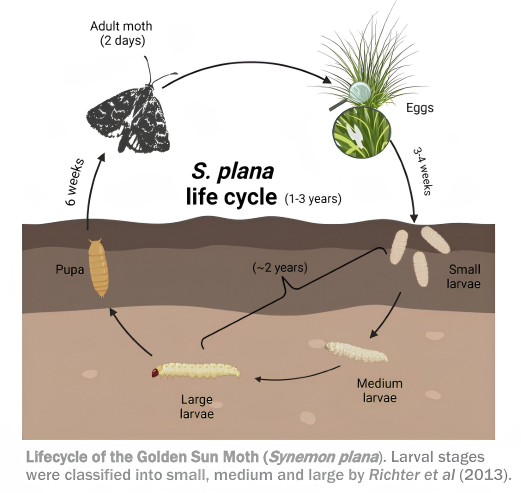

In [127]:
import numpy as np # For numerical operations, especially with arrays.
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualisations.
import pandas as pd # For data manipulation and analysis, especially with DataFrames.
import seaborn as sns # For making statistical graphics based on matplotlib.
from scipy.stats import linregress # For performing simple linear regression.
import statsmodels.formula.api as smf # For defining statistical models using formulas.
import statsmodels.api as sm # For fitting various statistical models.

In [128]:
# Apply a global seaborn theme for consistent aesthetics.
sns.set_theme(style="whitegrid", palette="viridis")

## **Transect field data - collected Nov/Dec 2025**

Upload the project data file 'moth_transects.xlsx' and use pandas to read in the first datasheet containing cleaned field data.

Extensive cleaning was completed in Excel prior to analysis. **Notes on all data cleaning steps can be found in the 'Cleaning notes' sheet in the Excel file.**

The following cells:
* Read in the datasheet and create a DataFrame
* Display the first few rows of the DataFrame

In [129]:
# Load the dataset from an Excel file named 'moth_transects.xlsx'.
# The data is specifically taken from the sheet named 'transect_data'.
df = pd.read_excel("moth_transects.xlsx", sheet_name='transect_data')

# Display the first few rows of the DataFrame to get an overview of the data structure.
df.head()

,Obs ID,Date,Reserve,Site,Transect,Segment,site_id,Time Start,Time End,time_of_day,...,OTHER SPECIES,Other species count,insect_richness,Transect - Males,Transect - Felmales,moth_count,NOTES,Column4,Column5,Column6
0,ID_1,2025-11-03,G,1,1,1,ID_1-G-1-1-1,10:43:00,10:53:00,10.716667,...,"Checkered Copper, White moth",2,7,0,0,0,NaN,NaN,NaN,NaN
1,ID_2,2025-11-03,G,1,1,1,ID_2-G-1-1-1,10:43:00,10:53:00,10.716667,...,"Fly, Blue forester, Bee, Checkered Copper, Whi...",5,8,0,0,0,Early iteration of data sheet without species ...,NaN,NaN,NaN
2,ID_3,2025-11-03,G,1,2,1,ID_3-G-1-2-1,10:59:00,11:10:00,10.983333,...,"Beetles (?), Checkered Copper",2,6,0,0,0,Early iteration of data sheet without species ...,NaN,NaN,NaN
3,ID_4,2025-11-03,G,1,2,1,ID_4-G-1-2-1,10:59:00,11:10:00,10.983333,...,NaN,0,3,0,0,0,NaN,NaN,NaN,NaN
4,ID_5,2025-11-03,G,1,3,1,ID_5-G-1-3-1,11:13:00,11:24:00,11.216667,...,"Fly, Brown moth, Bee",3,6,0,0,0,Early iteration of data sheet without species ...,NaN,NaN,NaN


## **Analytical Approach**

To investigate how environmental conditions influence observed Golden Sun Moth abundance, this analysis follows a structured workflow:

1. **Exploratory Data Analysis (EDA)** – to identify patterns, variability, and potential relationships between environmental variables and moth counts.
2. **Correlation and Linear Regression** – to quantify linear relationships between moth counts and environmental variables.
3. **Bootstrap Analysis** – to assess uncertainty in regression estimates and determine whether observed relationships are robust.
4. **Lagged Temperature Analysis** – to test whether prior environmental conditions influence observed moth counts, aiming to pinpoint when they typically emerge.
5. **Generalised Linear Models (Negative Binomial)** – to account for the count-based nature of moth data and potential overdispersion.
6. **Uncertainty Modelling (Monte Carlo Simulations)** – to assess how imperfect detection influences observed relationships.

This combination of methods allows both identification of patterns and explicit quantification of uncertainty, which is critical when interpreting ecological field data.

## **Exploratory Data Analysis (EDA)**

### **Overview**
This section explores patterns in moth counts across key environmental variables using scatter plots and correlation analysis. Exploratory data analysis was used to understand the structure and variability of the dataset before applying statistical methods.

Scatter plots help identify whether relationships are linear, non-linear, or absent, while the correlation matrix quantifies the strength of linear associations and guides subsequent analysis.

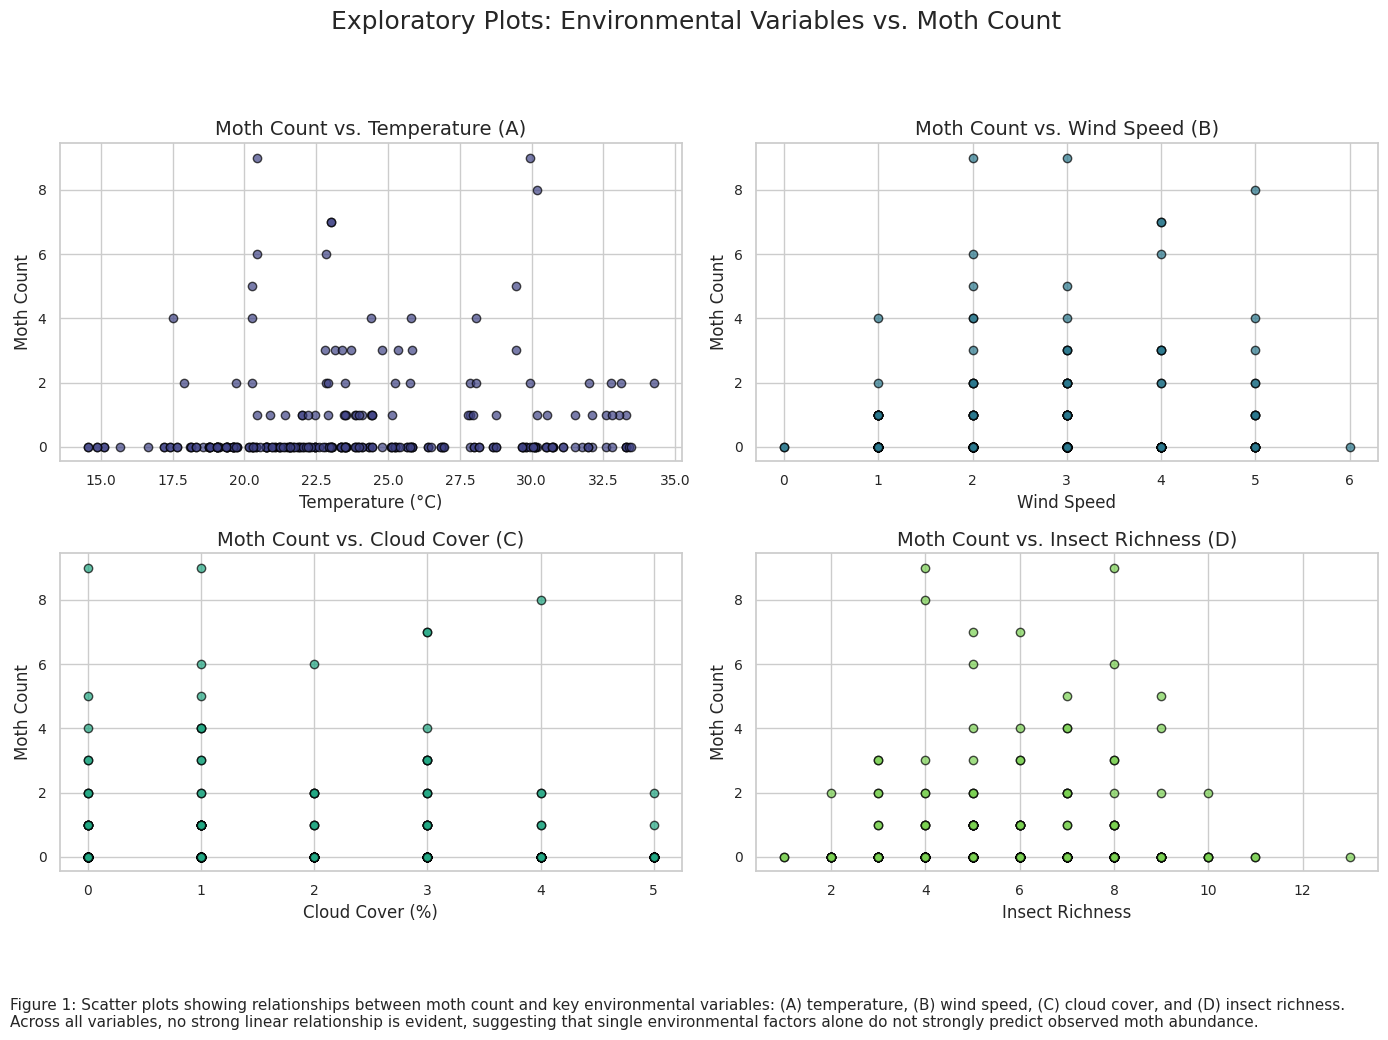

In [149]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
axes = ax.flatten()

variables = ['temp_avg', 'wind_speed', 'cloud_cover', 'insect_richness']
colors = sns.color_palette("viridis", n_colors=len(variables))

axes[0].scatter(df['temp_avg'], df['moth_count'], color=colors[0], alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Temperature (°C)', fontsize=12)
axes[0].set_ylabel('Moth Count', fontsize=12)
axes[0].set_title('Moth Count vs. Temperature (A)', fontsize=14)
axes[0].tick_params(axis='x', labelsize=10)
axes[0].tick_params(axis='y', labelsize=10)

axes[1].scatter(df['wind_speed'], df['moth_count'], color=colors[1], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Wind Speed', fontsize=12)
axes[1].set_ylabel('Moth Count', fontsize=12)
axes[1].set_title('Moth Count vs. Wind Speed (B)', fontsize=14)
axes[1].tick_params(axis='x', labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)

axes[2].scatter(df['cloud_cover'], df['moth_count'], color=colors[2], alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Cloud Cover (%)', fontsize=12)
axes[2].set_ylabel('Moth Count', fontsize=12)
axes[2].set_title('Moth Count vs. Cloud Cover (C)', fontsize=14)
axes[2].tick_params(axis='x', labelsize=10)
axes[2].tick_params(axis='y', labelsize=10)

axes[3].scatter(df['insect_richness'], df['moth_count'], color=colors[3], alpha=0.7, edgecolor='black')
axes[3].set_xlabel('Insect Richness', fontsize=12)
axes[3].set_ylabel('Moth Count', fontsize=12)
axes[3].set_title('Moth Count vs. Insect Richness (D)', fontsize=14)
axes[3].tick_params(axis='x', labelsize=10)
axes[3].tick_params(axis='y', labelsize=10)

fig.suptitle('Exploratory Plots: Environmental Variables vs. Moth Count', fontsize=18, y=1.03)

caption_text_1 = "Figure 1: Scatter plots showing relationships between moth count and key environmental variables: (A) temperature, (B) wind speed, (C) cloud cover, and (D) insect richness. Across all variables, no strong linear relationship is evident, suggesting that single environmental factors alone do not strongly predict observed moth abundance."
plt.figtext(0.01, 0.01, caption_text_1, ha='left', va='bottom', fontsize=11, wrap=True)

plt.tight_layout(rect=[0, 0.1, 1, 0.98])
plt.show()

**Figure 1** shows no clear linear relationship between moth count and the examined environmental variables. While slight positive trends may be visible for temperature and wind speed, the high variability across similar conditions suggests these variables alone are not strong predictors of observed counts, and may reflect behavioural responses, microclimatic variation, or inconsistencies in detection during surveys.

## **Correlation Analysis**

**Table 1** and **Figure 2** present the correlation matrix and corresponding heatmap, showing pairwise relationships between moth count and key environmental variables (temperature, wind speed, cloud cover, and insect richness).

Correlation analysis was used to quantify linear relationships and provide a baseline understanding before applying more complex models. It allowed for quick identification of whether any variables showed clear associations with moth counts.

In [131]:
# Calculate the correlation matrix for selected variables.
# This helps to understand the linear relationships between moth count and environmental factors.
corr = df[['moth_count', 'temp_avg', 'wind_speed', 'cloud_cover', 'insect_richness']].corr()

# Display the correlation matrix as Table 1
print("Table 1: Correlation Matrix of Environmental Variables and Moth Count")
display(corr.style.format(formatter='{:.2f}').set_table_attributes('style="display:inline"'))

Table 1: Correlation Matrix of Environmental Variables and Moth Count


,moth_count,temp_avg,wind_speed,cloud_cover,insect_richness
moth_count,1.00,0.10,0.15,-0.04,0.02
temp_avg,0.10,1.00,0.20,0.00,-0.26
wind_speed,0.15,0.20,1.00,0.22,-0.13
cloud_cover,-0.04,0.00,0.22,1.00,-0.20
insect_richness,0.02,-0.26,-0.13,-0.20,1.00


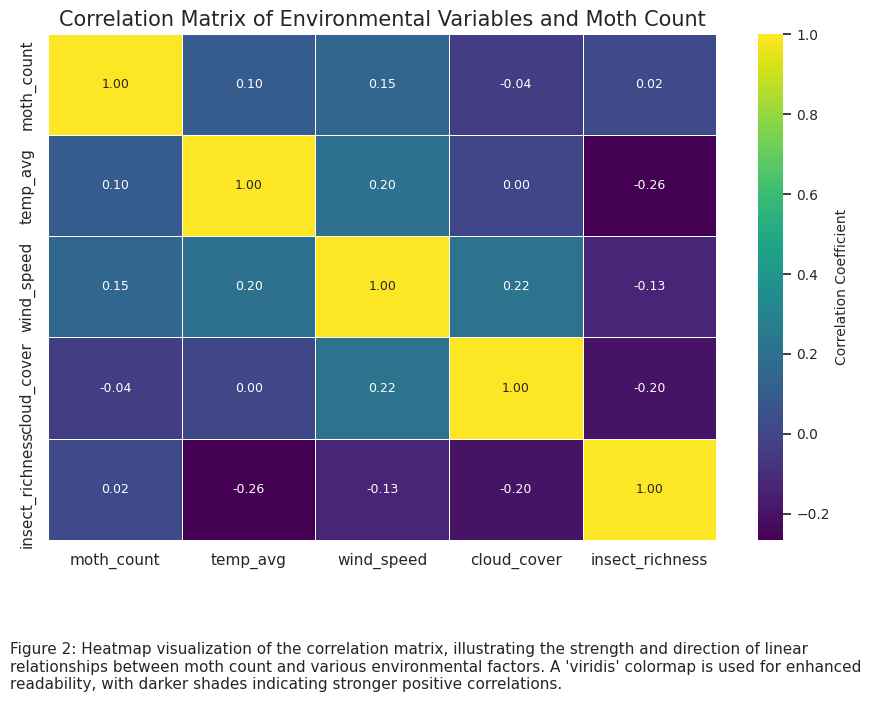

In [132]:
# Display the correlation matrix as a heatmap for better visualisation of relationships.
plt.figure(figsize=(9, 7))
ax = sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f", linewidths=.7, linecolor='white', cbar_kws={'label': 'Correlation Coefficient'}, annot_kws={
        "fontsize": 9
    })
cb = ax.collections[0].colorbar # Get the colorbar object
cb.set_label('Correlation Coefficient', fontsize=10) # Set colorbar label fontsize
cb.ax.tick_params(labelsize=10) # Set colorbar tick labels fontsize

plt.title("Correlation Matrix of Environmental Variables and Moth Count", fontsize=15)

caption_text_2 = "Figure 2: Heatmap visualization of the correlation matrix, illustrating the strength and direction of linear relationships between moth count and various environmental factors. A 'viridis' colormap is used for enhanced readability, with darker shades indicating stronger positive correlations."
plt.figtext(0.01, -0.05, caption_text_2, ha='left', va='bottom', fontsize=11, wrap=True)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

The correlation matrix (**Figure 2**) shows generally weak relationships between moth count and all environmental variables, with coefficients close to zero.

This indicates that linear relationships between individual environmental variables and moth abundance are weak, likely reflecting the influence of multiple interacting factors as well as variability in detection during field surveys.



### **Grouped Hour Comparison (**Figure 3**)**


During field collection, it often felt like moth abundance varied at different times of day, with some periods appearing to have higher counts than others.

To explore this more systematically, moth counts were grouped by hour to assess whether consistent diurnal patterns were present. This provides a simple comparison of abundance across time without assuming a linear relationship.


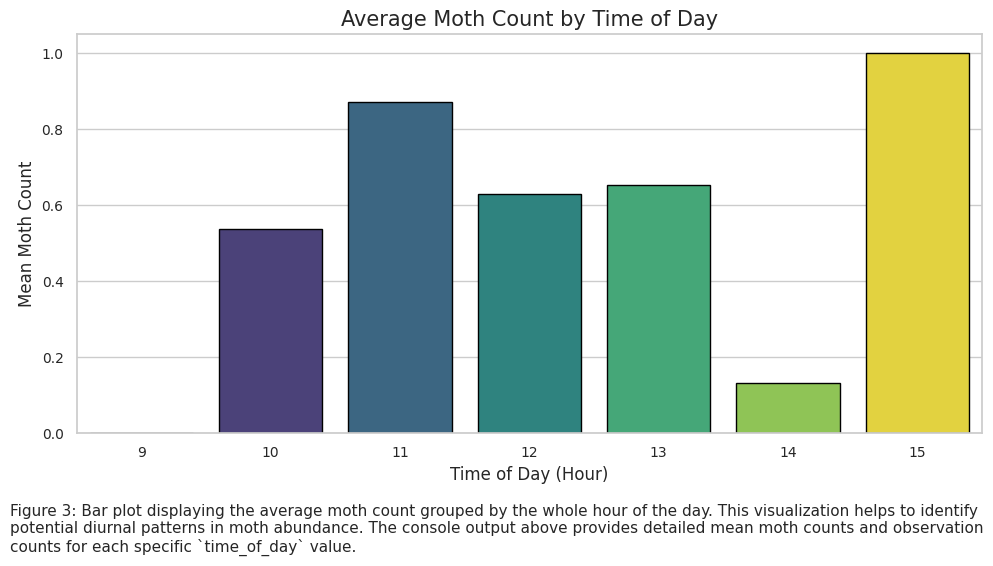

In [148]:
# GROUP COMPARISON (basic summary of moth counts by time of day)

plot_groups = df.groupby(df['time_of_day'].astype(int))['moth_count'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=plot_groups.index, y=plot_groups.values, ax=ax, palette="viridis", hue=plot_groups.index, legend=False, edgecolor='black')

ax.set_ylabel('Mean Moth Count', fontsize=12)
ax.set_xlabel('Time of Day (Hour)', fontsize=12)
ax.set_title('Average Moth Count by Time of Day', fontsize=15)
ax.set_xticks(range(len(plot_groups.index)))
ax.set_xticklabels(plot_groups.index, rotation=0, fontsize=10)
ax.tick_params(axis='y', labelsize=10)

caption_text_4 = "Figure 3: Bar plot displaying the average moth count grouped by the whole hour of the day. This visualization helps to identify potential diurnal patterns in moth abundance. The console output above provides detailed mean moth counts and observation counts for each specific `time_of_day` value."
plt.figtext(0.01, 0.01, caption_text_4, ha='left', va='bottom', fontsize=11, wrap=True)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()


**Figure 3** suggests that moth count does not vary strongly across hours of the day within the sampled period. While small fluctuations are visible, these differences are inconsistent, indicating that time of day alone is unlikely to be a dominant driver of observed abundance within the survey window. This may reflect that surveys were conducted during a relatively narrow period of suitable conditions.

As this analysis did not reveal a clear pattern, the focus shifted to other environmental variables. In addition, sampling times were not evenly distributed throughout the day and may have been influenced by factors such as breaks or survey timing constraints. This means the data are not uniformly collected, which may further limit the ability to detect any true diurnal patterns.

## **Basic Regression Results: Primary Environmental Variables**

This section presents regression analyses for key environmental variables (`temp_avg`, `wind_speed`, `cloud_cover`, `insect_richness`) against moth count.

### **Simple Linear Regression Results**
**Table 2** displays the regression coefficient and R² values for each variable.

Linear regression was used as an initial modelling approach because it provides a simple and consistent way to test for relationships between environmental variables and moth count. Although ecological relationships are often non-linear, it serves as a useful baseline for identifying any clear directional trends.


In [134]:
# Define the environmental variables for which to perform simple linear regression.
variables = ['temp_avg', 'wind_speed', 'cloud_cover', 'insect_richness']

results = {} # Initialise an empty dictionary to store regression results.

# Loop through each environmental variable to perform simple linear regression.
for var in variables:
    # Perform linear regression using scipy.stats.linregress.
    # It returns the slope (regression_coefficient), intercept, r-value, p-value, and standard error.
    regression_coefficient, intercept, r, p, se = linregress(df[var], df['moth_count'])
    # Store the regression coefficient and R-squared value (r**2) in the results dictionary.
    results[var] = {'regression_coefficient': regression_coefficient, 'r2': r**2}

# Convert the results dictionary to a pandas DataFrame for a clean tabular display.
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.index.name = 'Variable' # Name the index column 'Variable'.

# Display the DataFrame with enhanced styling as Table 2
print("Table 2: Simple Linear Regression Results")
display(results_df.style.format(formatter='{:.3f}').set_table_attributes('style="display:inline"'))

Table 2: Simple Linear Regression Results


,regression_coefficient,r2
Variable,,
temp_avg,0.031,0.009
wind_speed,0.201,0.024
cloud_cover,-0.035,0.002
insect_richness,0.013,0.000


The regression results (**Table 2**) show consistently low R² values across all variables, indicating that individual environmental factors explain very little variation in moth count.

This supports the patterns observed in **Figure 1** and suggests that moth counts are not strongly driven by any single environmental variable when considered in isolation.

### **Bootstrap Analysis of Regression Slopes (Figure 4)**

The initial regression results suggested weak relationships between environmental variables and moth count. However, linear regression provides only a single estimate of each relationship.

To better understand the uncertainty in these estimates, a bootstrap approach was used. This involves repeatedly resampling the dataset and recalculating regression slopes to generate a distribution of possible values. This allows assessment of how stable the estimated relationships are and whether they are consistently positive, negative, or highly variable.

temp_avg CI: [-0.00378462  0.06919227]
wind_speed CI: [0.04446125 0.37393222]
cloud_cover CI: [-0.12460276  0.05836581]
insect_richness CI: [-0.06685083  0.09503994]


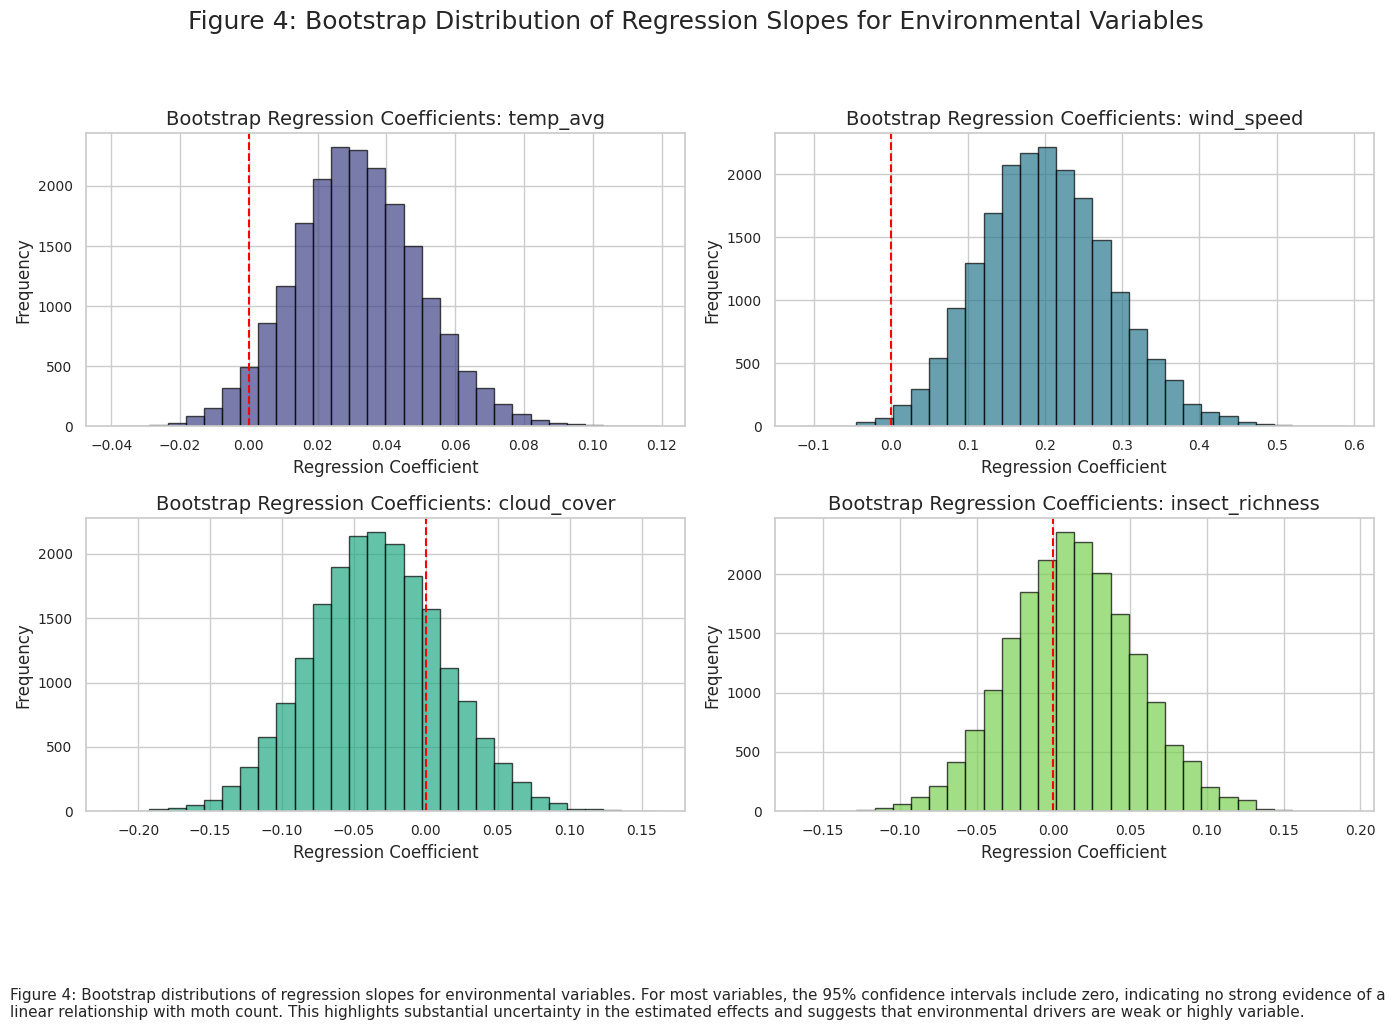

In [135]:
# Initialise a dictionary to store bootstrap results for each variable.
bootstrap_results = {}

# Create a single figure with a 2x2 grid of subplots.
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # Increased figure size for better readability
axes = axes.flatten()

# Define the variables for which to perform bootstrapping.
variables = ['temp_avg', 'wind_speed', 'cloud_cover', 'insect_richness']
colors = sns.color_palette("viridis", n_colors=len(variables)) # Use the 'viridis' color palette for consistency

# Loop through each variable and its corresponding subplot index.
for i, var in enumerate(variables):
    slopes = []

    # Perform 20,000 bootstrap samples.
    for _ in range(20000):
        sample = df.sample(frac=1, replace=True)
        regression_coefficient, _, _, _, _ = linregress(sample[var], sample['moth_count'])
        slopes.append(regression_coefficient)

    bootstrap_results[var] = slopes

    axes[i].hist(slopes, bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Bootstrap Regression Coefficients: {var}', fontsize=14)
    axes[i].set_xlabel('Regression Coefficient', fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)

    ci = np.percentile(slopes, [2.5, 97.5])
    print(f"{var} CI: {ci}")

fig.suptitle('Figure 4: Bootstrap Distribution of Regression Slopes for Environmental Variables', fontsize=18, y=1.02)

caption_text_3 = "Figure 4: Bootstrap distributions of regression slopes for environmental variables. For most variables, the 95% confidence intervals include zero, indicating no strong evidence of a linear relationship with moth count. This highlights substantial uncertainty in the estimated effects and suggests that environmental drivers are weak or highly variable."
plt.figtext(0.01, 0.01, caption_text_3, ha='left', va='bottom', fontsize=11, wrap=True)

plt.tight_layout(rect=[0, 0.15, 1, 0.98])
plt.show()


The bootstrap results (**Figure 4**) show that regression coefficients vary widely across all variables. For most variables, the 95% confidence intervals include zero, indicating that the estimated relationships are not statistically robust.

This suggests that the observed trends are highly sensitive to sampling variability and may not represent consistent underlying ecological effects. While linear regression provides a single estimate of each relationship, bootstrapping shows a range of possible outcomes, giving a clearer picture of uncertainty.

Overall, these results indicate that there is no strong evidence that any single environmental variable has a consistent linear effect on moth abundance in this dataset.


---

# **Further Analysis: Lagged Temperature Effects on Moth Count**

### **Rationale for Lagged Temperature Variables**
Maximum daily temperature data from the Bureau of Meteorology (BoM) were used to calculate conditions for the three days preceding each transect observation. This time window reflects the short adult lifespan of the Golden Sun Moth (approximately 1–3 days), representing the period over which prior environmental conditions may influence observed abundance.

Given this biology, it was expected that environmental conditions in the days prior to observation could influence emergence and abundance. This analysis therefore explores whether higher temperatures in the days before a survey are associated with increased moth counts.

While this approach cannot establish causation, it provides insight into whether recent temperature history — rather than just conditions at the time of survey — may better explain variation in moth counts.

### **Derived Variables**
In addition to individual lagged temperatures (1-day, 2-day, and 3-day prior), a mean prior maximum temperature was calculated. This provides a smoothed measure of recent thermal conditions, allowing comparison between short-term variation and overall temperature trends leading up to observations.


### **Visualising the relationship between 'moth_count' and lagged maximum temperature features (**Figure 5**).**


This section explores how moth count varies with temperatures in the days prior to each observation. Lagged temperature variables (1–3 days prior and mean prior temperature) are compared with moth count to assess whether recent environmental conditions influence observed abundance.


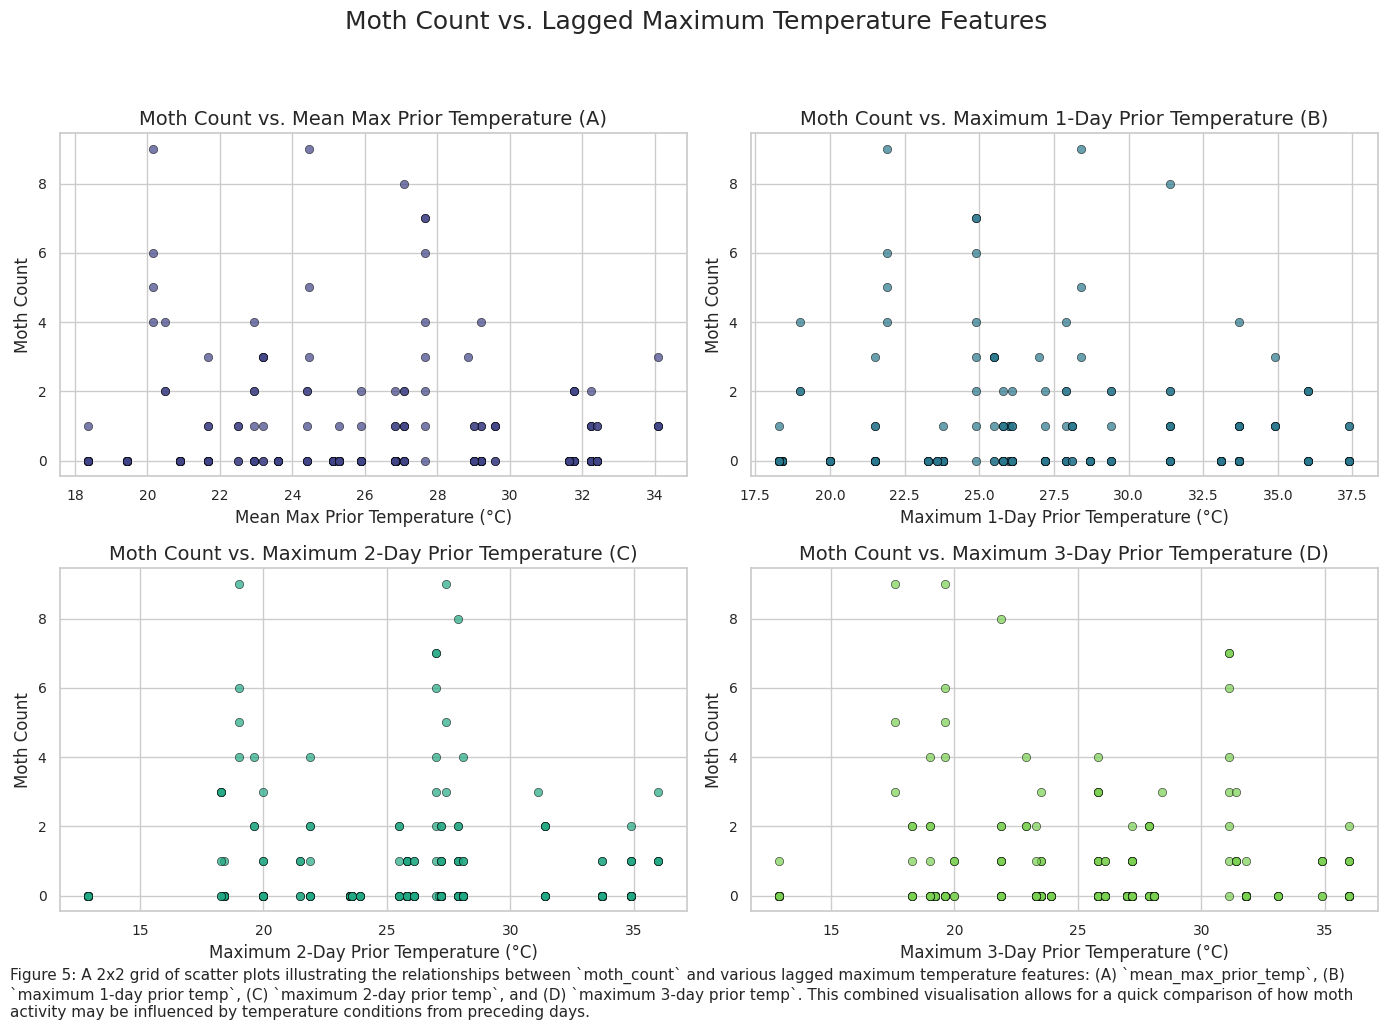

In [136]:
# Set theme and use a distinct color palette

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
axes = ax.flatten()

lagged_temp_vars = [
    ('mean_max_prior_temp', 'Mean Max Prior Temperature (A)'),
    ('1_day_prior_temp', 'Maximum 1-Day Prior Temperature (B)'),
    ('2_day_prior_temp', 'Maximum 2-Day Prior Temperature (C)'),
    ('3_day_prior_temp', 'Maximum 3-Day Prior Temperature (D)')
]

colors = sns.color_palette("viridis", n_colors=len(lagged_temp_vars)) # Using the 'viridis' color palette for consistency

for i, (var, title) in enumerate(lagged_temp_vars):
    sns.scatterplot(data=df, x=var, y='moth_count', ax=axes[i], color=colors[i], alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Moth Count vs. {title}', fontsize=14)
    axes[i].set_xlabel(f'{title.split(" (")[0]} (°C)', fontsize=12)
    axes[i].set_ylabel('Moth Count', fontsize=12)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)

fig.suptitle('Moth Count vs. Lagged Maximum Temperature Features', fontsize=18, y=1.02)

caption_text_7 = "Figure 5: A 2x2 grid of scatter plots illustrating the relationships between `moth_count` and various lagged maximum temperature features: (A) `mean_max_prior_temp`, (B) `maximum 1-day prior temp`, (C) `maximum 2-day prior temp`, and (D) `maximum 3-day prior temp`. This combined visualisation allows for a quick comparison of how moth abundance may be influenced by temperature conditions from preceding days."
plt.figtext(0.01, 0.01, caption_text_7, ha='left', va='bottom', fontsize=11, wrap=True)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()


**Figure 5** shows no clear relationship between moth count and lagged temperature variables. The absence of consistent trends across all time lags suggests that prior temperature conditions, within the 1–3 day window examined, do not strongly influence observed moth counts in this dataset. This may indicate that factors other than recent temperature, or more complex interactions, are driving variation in moth abundance.



## **Revised Simple Linear Regression for Lagged Temperatures**


### **Table 3**

**Table 3** presents the results of simple linear regression for moth count against each lagged temperature variable, including slope, intercept, R-value, p-value, and standard error. This provides an initial assessment of whether prior temperature conditions are associated with observed moth abundance.


In [137]:
lagged_temps = ['mean_max_prior_temp', '1_day_prior_temp', '2_day_prior_temp', '3_day_prior_temp']

print("### Simple Linear Regression Results for Lagged Temperatures ###")

all_slr_results = {}

for temp_col in lagged_temps:
    slope, intercept, r_value, p_value, std_err = linregress(df[temp_col], df['moth_count'])

    all_slr_results[temp_col] = {
        'Slope': slope,
        'Intercept': intercept,
        'R-value': r_value,
        'P-value': p_value,
        'Std. Error': std_err
    }

# Display the DataFrame with enhanced styling as Table 3
print("Table 3: Simple Linear Regression Results for Lagged Temperatures")
display(pd.DataFrame.from_dict(all_slr_results, orient='index').style.format(formatter='{:.4f}').set_table_attributes('style="display:inline"'))

### Simple Linear Regression Results for Lagged Temperatures ###
Table 3: Simple Linear Regression Results for Lagged Temperatures


,Slope,Intercept,R-value,P-value,Std. Error
mean_max_prior_temp,-0.0012,0.6505,-0.0038,0.9507,0.0201
1_day_prior_temp,0.0100,0.3556,0.0391,0.5224,0.0156
2_day_prior_temp,-0.0000,0.6190,-0.0001,0.9989,0.0153
3_day_prior_temp,-0.0120,0.9206,-0.0473,0.4387,0.0154


The regression results for lagged temperatures confirm the absence of a strong relationship. Low R-values and non-significant p-values across all variables indicate that prior temperature conditions do not strongly influence observed moth counts when considered independently within this dataset.

## **Revised Bootstrap Regression for Lagged Temperatures**

### **Table 4**

**Table 4** presents the bootstrap regression results for moth count against each lagged temperature variable. It includes the mean slope and intercept, along with their 95% confidence intervals, based on 1000 bootstrap samples.

These results provide an estimate of the uncertainty around the regression coefficients and allow assessment of how stable the relationships are across resampled datasets.

In [138]:
lagged_temps = ['mean_max_prior_temp', '1_day_prior_temp', '2_day_prior_temp', '3_day_prior_temp']
n_bootstraps = 1000

print("### Bootstrap Regression Results for Lagged Temperatures ###")

all_bootstrap_results = {}

for temp_col in lagged_temps:
    bootstrap_slopes = []
    bootstrap_intercepts = []

    for _ in range(n_bootstraps):
        resampled_df = df.sample(n=len(df), replace=True)
        slope_b, intercept_b, _, _, _ = linregress(resampled_df[temp_col], resampled_df['moth_count'])
        bootstrap_slopes.append(slope_b)
        bootstrap_intercepts.append(intercept_b)

    lower_bound_slope = np.percentile(bootstrap_slopes, 2.5)
    upper_bound_slope = np.percentile(bootstrap_slopes, 97.5)
    lower_bound_intercept = np.percentile(bootstrap_intercepts, 2.5)
    upper_bound_intercept = np.percentile(bootstrap_intercepts, 97.5)

    print(f"\nBootstrap Regression for moth_count vs. {temp_col} (n={n_bootstraps} bootstraps):")
    print(f"  Mean Slope: {np.mean(bootstrap_slopes):.4f} (95% CI: [{lower_bound_slope:.4f}, {upper_bound_slope:.4f}])")
    print(f"  Mean Intercept: {np.mean(bootstrap_intercepts):.4f} (95% CI: [{lower_bound_intercept:.4f}, {upper_bound_intercept:.4f}])")

    all_bootstrap_results[temp_col] = {
        'Mean Slope': np.mean(bootstrap_slopes),
        '95% CI (Slope)': f"[{lower_bound_slope:.4f}, {upper_bound_slope:.4f}]",
        'Mean Intercept': np.mean(bootstrap_intercepts),
        '95% CI (Intercept)': f"[{lower_bound_intercept:.4f}, {upper_bound_intercept:.4f}]"
    }

# Display the DataFrame with enhanced styling as Table 4
print("Table 4: Bootstrap Regression Results for Lagged Temperatures")
display(pd.DataFrame.from_dict(all_bootstrap_results, orient='index').style.format({
    'Mean Slope': '{:.4f}',
    '95% CI (Slope)': '{}',
    'Mean Intercept': '{:.4f}',
    '95% CI (Intercept)': '{}'
}).set_table_attributes('style="display:inline"'))

### Bootstrap Regression Results for Lagged Temperatures ###

Bootstrap Regression for moth_count vs. mean_max_prior_temp (n=1000 bootstraps):
  Mean Slope: -0.0019 (95% CI: [-0.0354, 0.0290])
  Mean Intercept: 0.6680 (95% CI: [-0.1470, 1.5832])

Bootstrap Regression for moth_count vs. 1_day_prior_temp (n=1000 bootstraps):
  Mean Slope: 0.0100 (95% CI: [-0.0131, 0.0312])
  Mean Intercept: 0.3568 (95% CI: [-0.2130, 1.0286])

Bootstrap Regression for moth_count vs. 2_day_prior_temp (n=1000 bootstraps):
  Mean Slope: 0.0005 (95% CI: [-0.0232, 0.0238])
  Mean Intercept: 0.6051 (95% CI: [0.0089, 1.2849])

Bootstrap Regression for moth_count vs. 3_day_prior_temp (n=1000 bootstraps):
  Mean Slope: -0.0120 (95% CI: [-0.0462, 0.0166])
  Mean Intercept: 0.9194 (95% CI: [0.1367, 1.8234])
Table 4: Bootstrap Regression Results for Lagged Temperatures


,Mean Slope,95% CI (Slope),Mean Intercept,95% CI (Intercept)
mean_max_prior_temp,-0.0019,"[-0.0354, 0.0290]",0.6680,"[-0.1470, 1.5832]"
1_day_prior_temp,0.0100,"[-0.0131, 0.0312]",0.3568,"[-0.2130, 1.0286]"
2_day_prior_temp,0.0005,"[-0.0232, 0.0238]",0.6051,"[0.0089, 1.2849]"
3_day_prior_temp,-0.0120,"[-0.0462, 0.0166]",0.9194,"[0.1367, 1.8234]"


The bootstrap results reinforce the absence of a strong relationship between lagged temperature variables and moth count. Across all variables, the confidence intervals include zero, indicating that the estimated effects are uncertain and not consistently positive or negative.

This suggests that prior temperature conditions do not have a stable or reliable influence on observed moth abundance within this dataset.


---

## **Negative Binomial Regression for Lagged Temperatures**

### **Rationale**

Negative Binomial regression was used as an additional modelling approach for moth count data. Unlike linear regression, this model is better suited to count data that are discrete and highly variable, and can account for overdispersion (where variability exceeds the mean).

This method was included to assess whether the absence of strong relationships observed in earlier analyses was due to limitations of the linear model or reflected underlying patterns in the data.

---

### **Table 5**

**Table 5** presents the Negative Binomial regression results for moth count against mean prior maximum temperature.


In [139]:
# Ensure moth_count is non-negative and integer type for Negative Binomial regression
df['moth_count'] = df['moth_count'].astype(int)

# Build the formula string
formula_mean_max = 'moth_count ~ mean_max_prior_temp'

# Fit the Negative Binomial model
nb_model_mean_max = smf.glm(formula=formula_mean_max, data=df, family=sm.families.NegativeBinomial())
nb_results_mean_max = nb_model_mean_max.fit()

print(f"\nNegative Binomial Regression for moth_count vs. mean_max_prior_temp:")
print(nb_results_mean_max.summary())


Negative Binomial Regression for moth_count vs. mean_max_prior_temp:
                 Generalized Linear Model Regression Results                  
Dep. Variable:             moth_count   No. Observations:                  270
Model:                            GLM   Df Residuals:                      268
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -290.65
Date:                Tue, 02 Jun 2026   Deviance:                       323.41
Time:                        04:37:25   Pearson chi2:                     584.
No. Iterations:                     7   Pseudo R-squ. (CS):          3.406e-05
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### **Table 6**

**Table 6** presents the Negative Binomial regression results for moth count against 1-day, 2-day, and 3-day prior temperature variables.

In [140]:
prior_day_temps = ['1_day_prior_temp', '2_day_prior_temp', '3_day_prior_temp']

for temp_col in prior_day_temps:
    print(f"\n{'='*80}")
    print(f"Negative Binomial Regression for moth_count vs. {temp_col}:")
    # The formula needs to handle column names that start with numbers by quoting them using Q() in patsy
    formula_individual = f'moth_count ~ Q("{temp_col}")'
    nb_model_individual = smf.glm(formula=formula_individual, data=df, family=sm.families.NegativeBinomial())
    nb_results_individual = nb_model_individual.fit()
    print(nb_results_individual.summary())


Negative Binomial Regression for moth_count vs. 1_day_prior_temp:
                 Generalized Linear Model Regression Results                  
Dep. Variable:             moth_count   No. Observations:                  270
Model:                            GLM   Df Residuals:                      268
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -290.13
Date:                Tue, 02 Jun 2026   Deviance:                       322.37
Time:                        04:37:25   Pearson chi2:                     596.
No. Iterations:                     7   Pseudo R-squ. (CS):           0.003884
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


The Negative Binomial regression results align with previous analyses, showing no significant relationship between lagged temperature variables and moth count.

Although Negative Binomial regression was not covered in this course, I chose to apply it after struggling to identify any clear relationships using the methods we had learned. This was done to explore whether the lack of results was due to the data itself or limitations of the models used. Given that the prior analyses already showed weak relationships, and this was a self-taught method, I opted to keep the model as simple as possible by not estimating the `alpha` dispersion parameter.

Through further research, I found that Negative Binomial regression is commonly used for ecological count data, where values are discrete and highly variable. Moth counts often include many low values and occasional high counts, which can violate the assumptions of linear regression. This model accounts for that variability by allowing for overdispersion, making it more appropriate for this type of data.

However, even with this more suitable model, the results remained weak. This suggests that temperature alone does not strongly predict observed moth counts, and that the lack of clear relationships likely reflects ecological complexity rather than an inappropriate analytical approach.

---

# **Monte Carlo Simulations for Detection Uncertainty**

To assess the impact of imperfect detection on the analysis, Monte Carlo simulations were used. Two scenarios are explored: a constant missed detection rate and a conditional (temperature-dependent) missed detection rate.

### **Why Monte Carlo Simulations?**
Monte Carlo simulation was used to explicitly explore uncertainty related to imperfect detection, which is a key limitation of field-based ecological data. Standard statistical models assume that observed counts reflect true abundance, which is unlikely in transect surveys.

By simulating missed detections under different scenarios, this approach tests how detection bias may influence the observed relationships. It allows the analysis to move beyond describing patterns in the data and instead assess how robust those patterns are under more realistic ecological assumptions.


### **Scenario 1: Constant Missed Detection Rate (20%)**

In this scenario, a constant missed detection rate of 20% is applied across all observations. This assumes that, on average, only 80% of moths present are detected during surveys.

This simulation tests how a consistent level of undercounting affects the estimated relationship between temperature and moth count.

Original linear regression slope (moth_count vs. temp_avg): 0.0312

Monte Carlo (Bootstrap) for moth_count vs. temp_avg with CONSTANT Missed Detection (20%):
  Mean Slope (adjusted): 0.0385 (95% CI: [-0.0023, 0.0847])


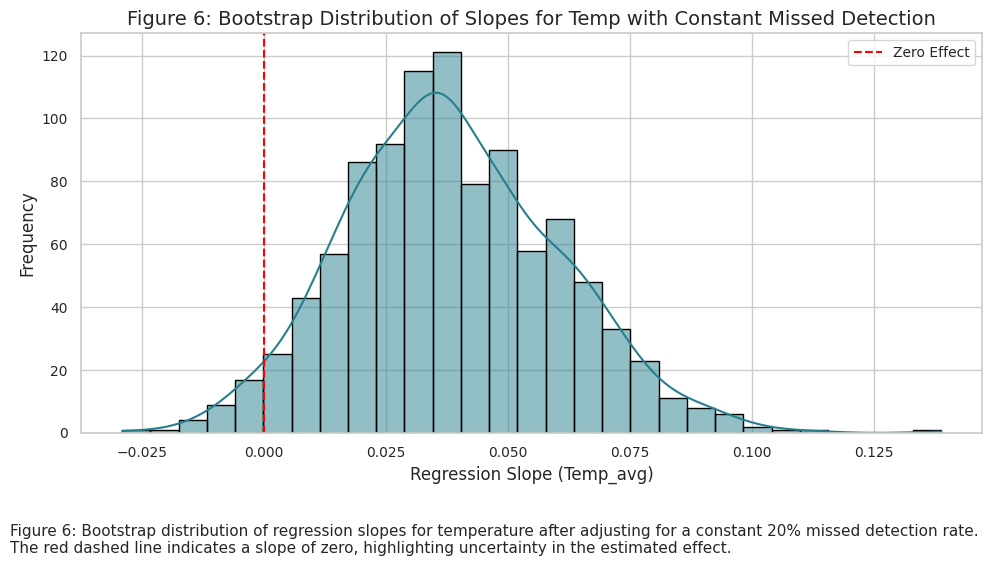

In [144]:
# Monte Carlo simulation: constant missed detection (20%)
n_simulations = 1000

missed_detection_rate_constant = 0.20

# Baseline relationship for reference
original_slope, _, _, _, _ = linregress(df['temp_avg'], df['moth_count'])
print(f"Original linear regression slope (moth_count vs. temp_avg): {original_slope:.4f}")

# Adjust counts to account for missed detections (observed = 80% of true)
adjusted_df = df.copy()
adjusted_df['moth_count_adjusted'] = adjusted_df['moth_count'] / (1 - missed_detection_rate_constant)

# Bootstrap regression on adjusted counts
boot_slopes_adjusted = []
for _ in range(n_simulations):
    resampled_adj_df = adjusted_df.sample(n=len(adjusted_df), replace=True)
    slope_b, _, _, _, _ = linregress(resampled_adj_df['temp_avg'], resampled_adj_df['moth_count_adjusted'])
    boot_slopes_adjusted.append(slope_b)

# Calculate confidence interval
lower_bound_slope_adj = np.percentile(boot_slopes_adjusted, 2.5)
upper_bound_slope_adj = np.percentile(boot_slopes_adjusted, 97.5)

print(f"\nMonte Carlo (Bootstrap) for moth_count vs. temp_avg with CONSTANT Missed Detection (20%):")
print(f"  Mean Slope (adjusted): {np.mean(boot_slopes_adjusted):.4f} (95% CI: [{lower_bound_slope_adj:.4f}, {upper_bound_slope_adj:.4f}])")

# Plot distribution of slopes
plt.figure(figsize=(10, 6))
sns.histplot(boot_slopes_adjusted, kde=True, color=sns.color_palette('viridis')[2], edgecolor='black') # Using a color from viridis palette
plt.axvline(x=0, color='red', linestyle='--', label='Zero Effect')
plt.title('Figure 6: Bootstrap Distribution of Slopes for Temp with Constant Missed Detection', fontsize=14)
plt.xlabel('Regression Slope (Temp_avg)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

caption_text_6 = "Figure 6: Bootstrap distribution of regression slopes for temperature after adjusting for a constant 20% missed detection rate. The red dashed line indicates a slope of zero, highlighting uncertainty in the estimated effect."
plt.figtext(0.01, 0.01, caption_text_6, ha='left', va='bottom', fontsize=11, wrap=True)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()


The results show that even with a consistent level of missed detection, the estimated relationship between temperature and moth count remains weak and uncertain. The confidence interval continues to include zero, indicating no statistically strong effect.

This suggests that simply adjusting for a constant level of undercounting does not reveal a stronger underlying relationship. Instead, it reinforces that the signal in the data is weak and may be dominated by variability rather than a clear environmental driver


### **Scenario 2: Conditional Missed Detection Rate (Temperature-Dependent: 15% missed >25°C, 30% missed <=25°C)**

In this scenario, the missed detection rate varies with temperature rather than remaining constant. Moths are assumed to be harder to detect on colder days and easier to detect on warmer days. This allows us to explore how temperature-dependent detection bias may influence the observed relationship between temperature and moth abundance.


Monte Carlo (Bootstrap) for moth_count vs. temp_avg with CONDITIONAL Missed Detection (Temperature-Dependent):
  Mean Slope (adjusted for conditional detection): 0.0284 (95% CI: [-0.0182, 0.0730])


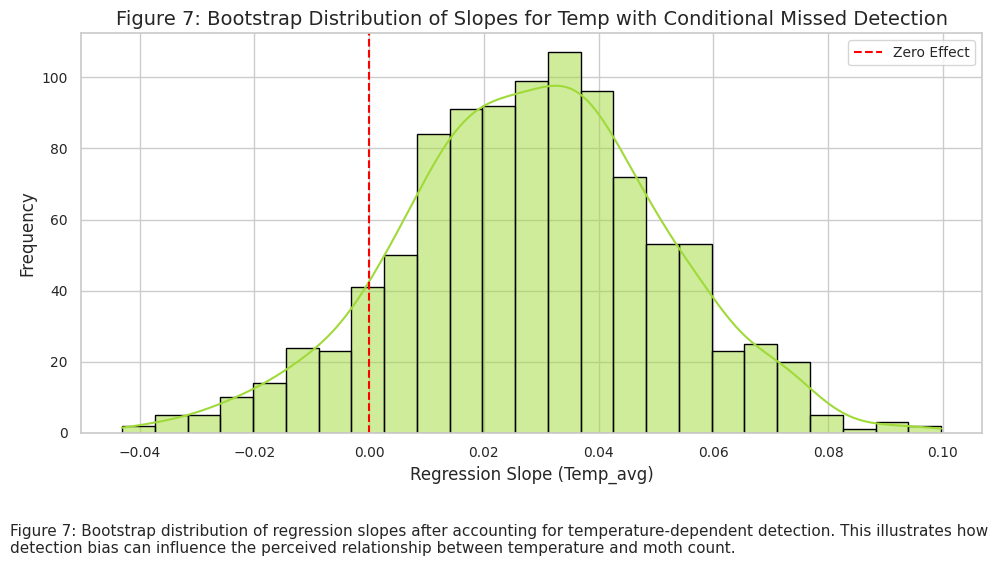

In [150]:
# Monte Carlo simulation: conditional (temperature-dependent) missed detection
n_simulations = 1000

# Detection probability depends on temperature threshold
def get_detection_probability(temp):
    if temp > 25:
        return 0.85 # 15% missed rate
    else:
        return 0.70 # 30% missed rate

# Note: min_temp_data and max_temp_data are no longer needed for this specific detection probability function
# However, the code below expects temp_avg to be passed, so we will adjust that part slightly to match the new function signature.

# Assume underlying relationship and adjust counts based on detection probability
true_beta_temp = 0.1
true_intercept = 0.5

hypothetical_true_moth_count = true_intercept + true_beta_temp * df['temp_avg']
hypothetical_true_moth_count = np.maximum(0, hypothetical_true_moth_count)

# Simulate observed counts adjusted for conditional detection and run bootstrap regression
boot_slopes_conditional_md = []
for _ in range(n_simulations):
    simulated_observed_moth_counts = []

    for i in range(len(df)):
        current_moth_count = df['moth_count'].iloc[i]
        current_temp_avg = df['temp_avg'].iloc[i]
        # Call the updated detection probability function
        detection_prob = get_detection_probability(current_temp_avg)

        adjusted_true_count = current_moth_count / detection_prob
        simulated_observed_moth_counts.append(adjusted_true_count)

    temp_sim_df = df.copy()
    temp_sim_df['simulated_true_moth_count'] = simulated_observed_moth_counts

    resampled_sim_df = temp_sim_df.sample(n=len(temp_sim_df), replace=True)
    slope_b, _, _, _, _ = linregress(resampled_sim_df['temp_avg'], resampled_sim_df['simulated_true_moth_count'])
    boot_slopes_conditional_md.append(slope_b)

# Calculate confidence interval
lower_bound_slope_cond = np.percentile(boot_slopes_conditional_md, 2.5)
upper_bound_slope_cond = np.percentile(boot_slopes_conditional_md, 97.5)

print(f"\nMonte Carlo (Bootstrap) for moth_count vs. temp_avg with CONDITIONAL Missed Detection (Temperature-Dependent):")
print(f"  Mean Slope (adjusted for conditional detection): {np.mean(boot_slopes_conditional_md):.4f} (95% CI: [{lower_bound_slope_cond:.4f}, {upper_bound_slope_cond:.4f}])")

# Plot distribution of slopes
plt.figure(figsize=(10, 6))
sns.histplot(boot_slopes_conditional_md, kde=True, color=sns.color_palette('viridis')[5], edgecolor='black') # Using a different color from viridis palette
plt.axvline(x=0, color='red', linestyle='--', label='Zero Effect')
plt.title('Figure 7: Bootstrap Distribution of Slopes for Temp with Conditional Missed Detection', fontsize=14)
plt.xlabel('Regression Slope (Temp_avg)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

caption_text_7 = "Figure 7: Bootstrap distribution of regression slopes after accounting for temperature-dependent detection. This illustrates how detection bias can influence the perceived relationship between temperature and moth count."
plt.figtext(0.01, 0.01, caption_text_7, ha='left', va='bottom', fontsize=11, wrap=True)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

These results show that detection processes can substantially influence observed relationships. When detection varies with temperature, the relationship between temperature and moth abundance becomes more uncertain and may be weakened or obscured.

While the specific missed detection rates used in these simulations are subjective, the assumption that detection probability varies with temperature is based on known ectothermal moth behaviour and observed flight patterns during data collection. Golden Sun Moths, like many ectotherms, are highly dependent on external temperatures for activity. On colder days, their activity levels are reduced, making them less likely to fly and thus harder to observe. Conversely, on warmer days, they are more active and visible. This aligns with field experience, where moths are rarely observed on very cold or windy days.

This highlights a key limitation of transect-based surveys: even if a real ecological relationship exists, it may not be clearly detected due to variability in observation. It reinforces the importance of accounting for detection uncertainty when interpreting ecological data.

---

# **Discussion and Conclusion**

This project investigated how environmental conditions influence observed Golden Sun Moth abundance during transect surveys, while explicitly accounting for uncertainty in real-world ecological data. A multi-faceted approach combining exploratory data analysis, regression modelling, and uncertainty analysis (bootstrapping and Monte Carlo simulations) was used to identify patterns and assess how reliable those patterns are.

## **Key Findings**

1.  **Weak relationships across environmental variables**:
    *   Exploratory analysis and correlation results (**Figure 1, Table 1, Figure 2**) showed generally weak relationships between moth count and environmental variables. Small positive correlations were observed for temperature (0.096) and wind speed (0.154), while cloud cover and insect richness showed little to no relationship.

    *   Lagged temperature variables also showed very low correlations with moth count (**Figure 5**), indicating that recent temperature conditions (1–3 days prior) did not strongly influence observed abundance.


2.  **Lagged temperature effects are not supported**:
    *   Regression analyses confirmed these patterns. Linear regression results showed very low R² values and non-significant p-values (**Table 3**), while bootstrap confidence intervals consistently included zero (**Table 4**).

    *   Negative Binomial regression, which is more appropriate for count data, produced similar results, with non-significant coefficients and very low explanatory power (**Tables 5** and **6**).

    *   Overall, these results suggest that prior temperature conditions do not have a strong linear effect on observed moth abundance when considered in isolation.


3.  **High uncertainty in estimated relationships**:
    *   Bootstrap analysis (**Figure 4**)  showed that regression coefficients varied widely, with most confidence intervals including zero. This indicates that the estimated relationships are highly sensitive to sampling variability.

    *   The grouped hour analysis (**Figure 3**)  showed small fluctuations in moth abundance throughout the day, but no consistent temporal effect within the survey window.

4. **Detection processes strongly influence results**:
    *   Monte Carlo simulations (**Figures 6** and **7**) showed that imperfect detection can influence observed relationships.
        *   Under a constant 20% missed detection rate, the temperature effect remained non-significant.

        *   Under temperature-dependent detection, the relationship became more uncertain and could be weakened or obscured.

    *   This suggests that even if a real ecological relationship exists, it may not be detectable due to detection bias.

---

## **Ecological Interpretation**
The absence of strong statistical relationships does not mean environmental factors are unimportant. Instead, it reflects ecological complexity and the limitations of observational data.

Golden Sun Moth abundance is likely influenced by multiple interacting factors — including temperature, solar radiation, wind, and habitat conditions — which may operate in non-linear ways and are not well captured by simple linear models. The high variability in moth counts under similar conditions suggests that additional unmeasured factors, such as microhabitat variation or emergence timing, also play an important role.

In addition, observed moth counts reflect both true abundance and detectability, meaning they are an imperfect measure of population size.

Together, these results highlight the challenge of separating ecological signals from observational noise in field-based studies.

---

## **Limitations**

This study is limited by:

* imperfect detection
* observer variability
* missing and inferred data
* small sample size
* lack of controlled conditions

These factors increase uncertainty and reduce the ability to detect clear relationships. As this is an observational dataset, causal relationships cannot be established.

---

# **Conclusion**
Although strong statistical relationships were not identified, the findings remain informative. They show that single environmental variables are unlikely to fully explain observed moth abundance and highlight the importance of considering uncertainty in ecological analysis.

For conservation monitoring, this suggests that survey design should incorporate multiple environmental variables, improve consistency in data collection, and account for detection bias.

More broadly, this project demonstrates that in ecological research, understanding uncertainty and limitations is just as important as identifying clear statistical relationships.

---

# **Acknowledgements**
I would like to thank Maisie Walker Stelling, a PhD candidate at the Fenner School of Environment & Society, for the opportunity to assist with field data collection over the summer. Her research on Golden Sun Moth translocation and population growth provided valuable context for this project, and it was rewarding to see this work develop from that experience.

I would also like to thank David Heslop for his guidance throughout the course. While I found the course challenging, it was highly engaging and valuable, particularly in developing my approach to data analysis and uncertainty. This project has strengthened my interest in data-driven ecological research, and I am keen to continue developing my coding and analytical skills.


---

# **Personal Reflection**
This project was motivated by my interest in applied ecology and my experience working with real-world environmental datasets. The Golden Sun Moth is a critically endangered species with highly specific activity requirements, making it an ideal case study for exploring how environmental conditions influence observed ecological patterns. I was particularly interested in understanding not only whether environmental variables affect moth abundance, but also how uncertainty in field data shapes these relationships.

A particularly rewarding aspect of this project was engaging with the full lifecycle of the data. I was involved in field collection, followed by data cleaning, analysis, and interpretation. Participating in fieldwork created a strong connection to the dataset and made the analytical process more meaningful. I also really valued the opportunity to spend time over the summer volunteering with my friend on her PhD field data collection, and it has been especially rewarding to see this project come directly out of that experience. Despite some results being weaker or less conclusive than expected, it was satisfying to carry the data through to final outputs. This experience reinforced the value of ecological monitoring and grounded the analysis in real-world observations rather than abstract data.

One of the main challenges was the complexity and “messiness” of the dataset. Although initial cleaning had been completed, further decisions were required during analysis, including handling missing values and interpreting subjective variables such as cloud cover and wind categories. Inconsistent sampling conditions also introduced variability. These challenges highlighted that working with ecological data requires ongoing judgement and careful assumptions, which must be considered to reduce bias.

Another key challenge was that many statistical analyses produced weak or non-significant results. I initially expected temperature to strongly influence moth abundance, given its known importance for insects. However, correlations were low and confidence intervals overlapped zero. While this was somewhat disappointing, it became an important learning experience. It reinforced that meaningful scientific outcomes are not always defined by strong or expected results, and that weak or uncertain findings can still be valuable.

In response, I shifted my focus toward interpretation and uncertainty, incorporating bootstrapping and Monte Carlo simulations. These approaches helped explore how detection bias and sampling variability influence observed patterns. In particular, modelling imperfect detection demonstrated how underlying ecological relationships may be obscured by observational processes, which is a key challenge in field studies.

This project has also shaped how I will approach future field data collection. It became clear that recording a broader range of environmental variables could improve the ability to detect meaningful patterns, including factors such as solar radiation, humidity, and more detailed wind measurements. Greater consistency in survey conditions and increased sampling frequency would also help reduce variability and strengthen future analyses.

Overall, this project strengthened my ability to work with complex ecological datasets and deepened my understanding of uncertainty in data analysis. It also reinforced the importance of critical thinking, persistence, and transparency when interpreting real-world data.

***A selection of photographs from the fieldwork associated with this project is provided below.***

## **Below are some photos from the field work collecting the data analysed in this notebook:**

#### **Image 1: Male GSM on ground** - note darker colours

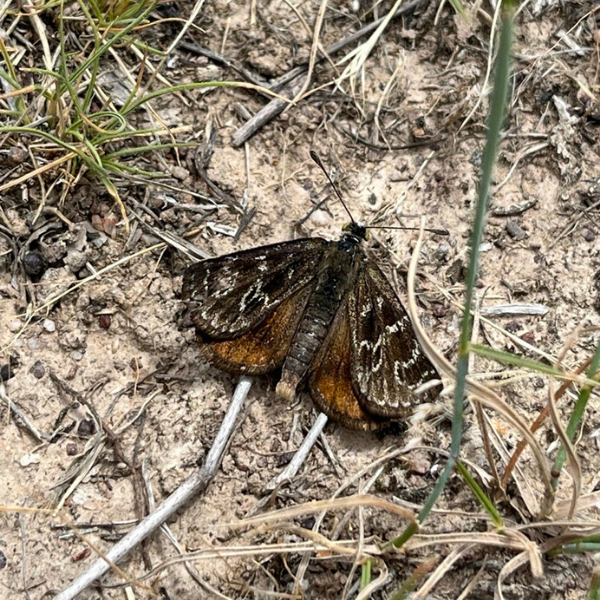

#### **Image 2: Female GSM** - this was a female we trapped while doing transects, with the goal to study if captive breeding is possible for GSMs. Note golden orange wings.

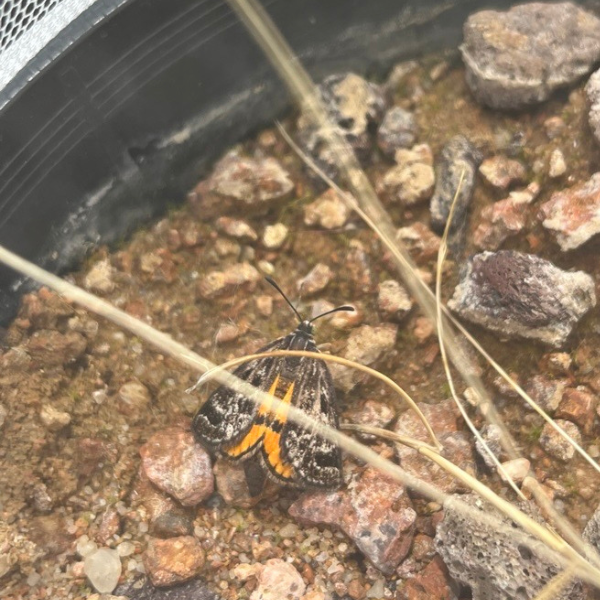

#### **Image 3: One of the many grassland study sites (camera monitors pictured)**

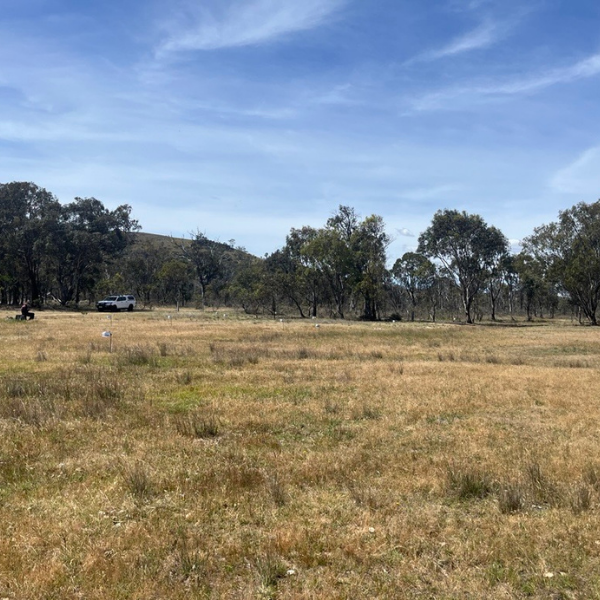